## 1. What this notebook computes

This notebook builds the complex numbers from zero and connects them with
rotations of the plane. It

- adds, multiplies and divides complex numbers in Python and exactly with
  sympy, and checks the rules of the modulus and of the conjugate;
- draws complex numbers as arrows in the plane;
- adds up the series $\sum_k (i\theta)^k / k!$ term by term and shows that it
  reaches $\cos\theta + i \sin\theta$ (Euler's formula), with a plot of how fast
  the error shrinks;
- shows that multiplying by $e^{i\alpha}$ rotates every point of the plane by the
  angle $\alpha$, and that the same rotation is a real $2 \times 2$ matrix; the
  real matrix $J$ that represents $i$ satisfies $J^2 = -I$;
- draws the roots of unity, the $n$ numbers with $z^n = 1$;
- shows that conjugation leaves every real number unchanged;
- compares rotations, which keep $x^2 + y^2$, with *boosts*, which keep
  $x^2 - t^2$ (one time-like and one space-like direction);
- shows that $e^{-i\varepsilon t}$ oscillates with modulus 1 when the frequency
  $\varepsilon$ is real, and grows exponentially when $\varepsilon$ is imaginary.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01b (Complex numbers, rotations and boosts) is the file
`Revision/textbook/notebooks/01b_complex_rotations.ipynb` of the repository Dirac_claude.
It computes with complex numbers in Python and exactly with sympy, draws them as arrows
in the plane, adds up the series of the exponential function to show Euler's formula and
how fast the series converges, shows that multiplying by a complex number of modulus 1
rotates the plane and that the same rotation is a real 2 by 2 matrix, draws the roots of
unity, shows that conjugation leaves real numbers unchanged, compares rotations, which
keep x squared plus y squared, with boosts, which keep x squared minus t squared, and
shows that a real frequency gives an oscillation while an imaginary frequency gives
exponential growth. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy, mpmath and matplotlib; the other packages run Jupyter, the program that shows and
runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01b_complex_rotations.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01b_complex_rotations.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01b_complex_rotations.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/01b.captions.json`,
`Revision/textbook/figures/01b_1_complex_plane.png`,
`Revision/textbook/figures/01b_2_euler_series.png`,
`Revision/textbook/figures/01b_3_rotation_by_multiplication.png`,
`Revision/textbook/figures/01b_4_roots_of_unity.png`,
`Revision/textbook/figures/01b_5_rotations_and_boosts.png` and
`Revision/textbook/figures/01b_6_oscillation_and_growth.png`. It changes no other file of
the repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 33 CHECKS PASSED (notebook 01b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01b_complex_rotations.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01b (Complex numbers, rotations and boosts) is the file
# Revision/textbook/notebooks/01b_complex_rotations.ipynb of the repository Dirac_claude.
# It computes with complex numbers in Python and exactly with sympy, draws them as arrows
# in the plane, adds up the series of the exponential function to show Euler's formula
# and how fast the series converges, shows that multiplying by a complex number of
# modulus 1 rotates the plane and that the same rotation is a real 2 by 2 matrix, draws
# the roots of unity, shows that conjugation leaves real numbers unchanged, compares
# rotations, which keep x squared plus y squared, with boosts, which keep x squared minus
# t squared, and shows that a real frequency gives an oscillation while an imaginary
# frequency gives exponential growth. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy, mpmath and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01b_complex_rotations.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01b_complex_rotations.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01b_complex_rotations.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/01b.captions.json,
# Revision/textbook/figures/01b_1_complex_plane.png,
# Revision/textbook/figures/01b_2_euler_series.png,
# Revision/textbook/figures/01b_3_rotation_by_multiplication.png,
# Revision/textbook/figures/01b_4_roots_of_unity.png,
# Revision/textbook/figures/01b_5_rotations_and_boosts.png and
# Revision/textbook/figures/01b_6_oscillation_and_growth.png. It changes no other file of
# the repository; running it headless or saving it in JupyterLab also rewrites the
# notebook file itself. It does not use the internet while it runs. The files it writes
# are the same files that are stored in the repository (on another computer a figure may
# differ in a few bytes, which is harmless). To get the stored versions back, run this
# command in the repository folder (it also undoes every change you made yourself in the
# folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 33 CHECKS PASSED (notebook 01b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01b_complex_rotations.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01b"  # this notebook: chapter 01, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Imaginary unit** $i$: a new number with $i^2 = -1$. Python writes it `1j`,
  sympy writes it `I`.
- **Complex number**: $z = a + ib$ with real numbers $a$ (the **real part**,
  $\mathrm{Re}\,z$) and $b$ (the **imaginary part**, $\mathrm{Im}\,z$).
- **Complex plane**: the plane in which $z = a + ib$ is the point (or the arrow
  from the origin to the point) $(a, b)$; horizontal axis $\mathrm{Re}$,
  vertical axis $\mathrm{Im}$.
- **Modulus** $|z| = \sqrt{a^2 + b^2}$: the length of the arrow.
- **Argument** (or **phase angle**): the angle between the arrow and the positive
  real axis, measured counterclockwise in radians ($\pi$ radians $= 180$
  degrees).
- **Conjugate** $z^* = a - ib$: the mirror image of $z$ in the real axis.
- **Series, partial sum**: an infinite sum $t_0 + t_1 + t_2 + \cdots$; its
  partial sum $S_N$ adds the terms $t_0$ to $t_N$. The series **converges** to a
  number $S$ when the error $|S_N - S|$ becomes as small as we like for large $N$.
- **Factorial** $k! = 1 \cdot 2 \cdots k$, with $0! = 1$.
- **Euler's formula**: $e^{i\theta} = \cos\theta + i \sin\theta$ for real
  $\theta$.
- **Polar form**: $z = r e^{i\varphi}$ with $r = |z|$ and $\varphi$ the argument.
- **Rotation**: turning the plane about the origin by an angle; it keeps every
  length. The **rotation matrix** of the angle $\alpha$ has the rows
  $(\cos\alpha, -\sin\alpha)$ and $(\sin\alpha, \cos\alpha)$.
- **Hyperbolic functions**: $\cosh\varphi = (e^{\varphi} + e^{-\varphi})/2$ and
  $\sinh\varphi = (e^{\varphi} - e^{-\varphi})/2$; they satisfy
  $\cosh^2\varphi - \sinh^2\varphi = 1$.
- **Boost**: the matrix with rows $(\cosh\varphi, \sinh\varphi)$ and
  $(\sinh\varphi, \cosh\varphi)$ acting on a pair $(t, x)$ of a time-like and a
  space-like coordinate; it keeps $x^2 - t^2$. The number $\varphi$ is its
  **rapidity**.
- **Root of unity**: a complex number $z$ with $z^n = 1$ for a whole number
  $n \geq 1$.
- **Frequency**: the number $\varepsilon$ in $e^{-i\varepsilon t}$; for real
  $\varepsilon$ the real and imaginary parts oscillate like $\cos$ and $\sin$.
- **mpmath**: a Python package that computes with as many decimal digits as
  requested (here 50).

## 4. The physical and mathematical situation

The fields of the author's theory, dirac16complex and dirac16complex00, have 16
*complex* components at every point of spacetime, and the waves that solve their
equations depend on the time $x_4$ through factors like $e^{-i\varepsilon x_4}$.
The author's gamma matrices, on the other hand, are *real*. This notebook shows
how the two fit together: a real $2 \times 2$ matrix $J$ with $J^2 = -I$ behaves
exactly like the number $i$, and multiplying by a complex number of modulus 1 is
the same as rotating with a real matrix.

Euler's formula $e^{i\theta} = \cos\theta + i\sin\theta$ comes from the series of
the exponential function, $e^x = \sum_{k=0}^\infty x^k/k!$, with $x = i\theta$:
the powers of $i$ repeat as $1, i, -1, -i, 1, \dots$, so the even terms build the
series of $\cos\theta$ and the odd terms $i$ times the series of $\sin\theta$.

The author's spacetime has four space-like directions ($x_1, x_2, x_3, x_8$,
where the frame metric $\eta$ has $+1$) and four time-like ones ($x_4$ to $x_7$,
where $\eta$ has $-1$). A transformation that mixes two directions of the same
kind is a rotation, which keeps $x^2 + y^2$; one that mixes a time-like with a
space-like direction is a boost, which keeps $x^2 - t^2$ and is built from
$\cosh$ and $\sinh$ instead of $\cos$ and $\sin$. A boost stretches one light-like
direction ($x = t$) by $e^{\varphi}$ and shrinks the other ($x = -t$) by
$e^{-\varphi}$: a growing and a shrinking exponential whose product is 1, the
same pattern as the factors $e^{a_4}$ of space and $e^{-a_4}$ of the extra times
in the author's metric.

Finally, the frequency $\varepsilon$ of a wave decides its fate: if $\varepsilon$
is real, $|e^{-i\varepsilon t}| = 1$ for all times; if $\varepsilon = i\gamma$ is
imaginary, $e^{-i\varepsilon t} = e^{\gamma t}$ grows (or shrinks) exponentially.
An imaginary frequency is the mathematical sign of an instability.

## 5. Complex numbers in Python and in sympy

The next cell computes with $z = 1 + 2i$ and $w = 3 - i$ in two ways. Python's
own complex numbers (written `1 + 2j`) are floating-point numbers. sympy's `I` is
the exact imaginary unit, so sympy gives exact results:

$(1 + 2i)(3 - i) = 3 - i + 6i - 2i^2 = 3 + 5i + 2 = 5 + 5i$, and
$\frac{1 + 2i}{3 - i} = \frac{(1 + 2i)(3 + i)}{(3 - i)(3 + i)} =
\frac{3 + i + 6i + 2i^2}{9 + 1} = \frac{1 + 7i}{10}$ (multiplying numerator and
denominator by the conjugate $3 + i$ of the denominator makes the denominator
real).

In [2]:
import cmath  # functions of complex numbers: phase (the argument), exp
import math  # cos, sin, exp, factorial of real numbers

import mpmath  # numbers with as many digits as we ask for
import numpy as np  # arrays of numbers
import sympy as sp  # exact arithmetic

z = 1 + 2j  # Python writes the imaginary unit as j, right after a number
w = 3 - 1j
say(f"Python: z = {z}, w = {w}, z + w = {z + w}, z w = {z * w}")
I = sp.I  # sympy's exact imaginary unit
z_exact = 1 + 2 * I
w_exact = 3 - I
product = sp.expand(z_exact * w_exact)  # multiply out, with I**2 = -1
quotient = sp.simplify(z_exact / w_exact)
say(f"sympy: z w = {product}, z / w = {quotient}")
check(I ** 2 == -1, "i^2 = -1")
check(product == 5 + 5 * I and complex(product) == z * w, "(1 + 2i)(3 - i) = 5 + 5i")
check(sp.simplify(quotient - (1 + 7 * I) / 10) == 0, "(1 + 2i)/(3 - i) = (1 + 7i)/10")

Python: z = (1+2j), w = (3-1j), z + w = (4+1j), z w = (5+5j)
sympy: z w = 5 + 5*I, z / w = 1/10 + 7*I/10
PASS i^2 = -1
PASS (1 + 2i)(3 - i) = 5 + 5i
PASS (1 + 2i)/(3 - i) = (1 + 7i)/10


The next cell checks the rules of the conjugate and the modulus for *all*
complex numbers $z = a + ib$ and $w = c + id$, with sympy symbols $a, b, c, d$
that stand for any real numbers:

- $(zw)^* = z^* w^*$: conjugating a product conjugates each factor;
- $z z^* = a^2 + b^2 = |z|^2$, a real number that is never negative;
- $|zw|^2 = |z|^2 |w|^2$, hence $|zw| = |z|\,|w|$: lengths multiply.

In [3]:
a, b, c, d = sp.symbols("a b c d", real=True)  # any real numbers
zz = a + b * I
ww = c + d * I
check(sp.expand(sp.conjugate(zz * ww) - sp.conjugate(zz) * sp.conjugate(ww)) == 0,
      "(z w)* = z* w* for all complex z and w")
check(sp.expand(zz * sp.conjugate(zz)) == a ** 2 + b ** 2,
      "z z* = a^2 + b^2 = |z|^2 for every z = a + i b")
check(sp.expand(zz * ww * sp.conjugate(zz * ww)
                - (a ** 2 + b ** 2) * (c ** 2 + d ** 2)) == 0,
      "|z w|^2 = |z|^2 |w|^2 for all complex z and w")
say(f"|z| = {sp.Abs(z_exact)}, |w| = {sp.Abs(w_exact)}, "
    f"|z w| = {sp.Abs(product)}")

PASS (z w)* = z* w* for all complex z and w
PASS z z* = a^2 + b^2 = |z|^2 for every z = a + i b
PASS |z w|^2 = |z|^2 |w|^2 for all complex z and w
|z| = sqrt(5), |w| = sqrt(10), |z w| = 5*sqrt(2)


## 6. Complex numbers as arrows

The next cell draws $z = 1 + 2i$, $w = 3 - i$, their sum $z + w = 4 + i$ (the
diagonal of the parallelogram spanned by $z$ and $w$: put the arrow $w$ at the
tip of $z$), the conjugate $z^* = 1 - 2i$ (the mirror image in the real axis) and
$iz = -2 + i$, which is $z$ turned by a right angle. The helper `arrow` draws a
complex number as an arrow from a starting point. The check confirms that $iz$
has the same length as $z$ and an argument larger by $\pi/2$ (`cmath.phase` gives
the argument).

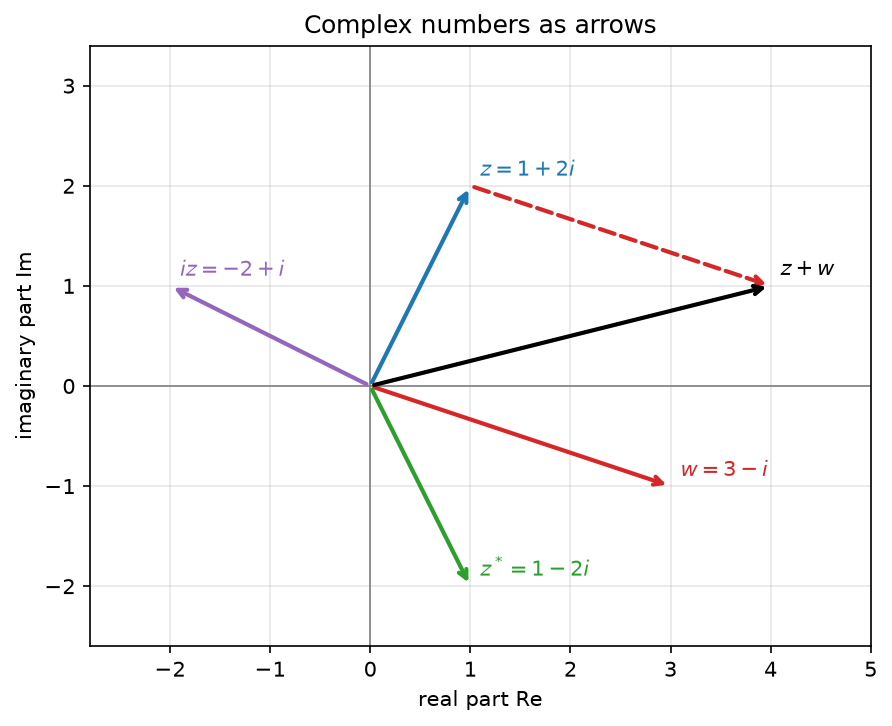

Figure 01b.1 saved as Revision/textbook/figures/01b_1_complex_plane.png
PASS multiplying by i keeps the length and turns by pi/2


In [4]:
def arrow(ax, number, color, label, start=0j, style="-"):
    """Draw the complex number as an arrow from start to start + number."""
    tip = start + number
    ax.annotate("", xy=(tip.real, tip.imag), xytext=(start.real, start.imag),
                arrowprops={"arrowstyle": "->", "color": color, "lw": 2,
                            "linestyle": style})
    ax.text(tip.real + 0.1, tip.imag + 0.1, label, color=color)


fig, ax = plt.subplots(figsize=(7.0, 5.2))
arrow(ax, z, "tab:blue", "$z = 1 + 2i$")
arrow(ax, w, "tab:red", "$w = 3 - i$")
arrow(ax, w, "tab:red", "", start=z, style="--")  # w moved to the tip of z
arrow(ax, z + w, "black", "$z + w$")
arrow(ax, z.conjugate(), "tab:green", "$z^* = 1 - 2i$")
arrow(ax, 1j * z, "tab:purple", "$iz = -2 + i$")
ax.axhline(0, color="0.5", lw=0.8)  # the real axis
ax.axvline(0, color="0.5", lw=0.8)  # the imaginary axis
ax.set_xlim(-2.8, 5.0)
ax.set_ylim(-2.6, 3.4)
ax.set_aspect("equal")
ax.set_xlabel("real part Re")
ax.set_ylabel("imaginary part Im")
ax.set_title("Complex numbers as arrows")
save_figure(fig, "complex_plane",
            "Complex numbers as arrows in the complex plane; horizontal axis the "
            "real part, vertical axis the imaginary part (pure numbers). Blue "
            "$z = 1 + 2i$, red $w = 3 - i$ (dashed: the same arrow moved to the tip "
            "of $z$), black their sum $z + w = 4 + i$, green the conjugate "
            "$z^{\\ast} = 1 - 2i$ (the mirror image of $z$ in the real axis) and "
            "purple $iz = -2 + i$, which is $z$ turned counterclockwise by a right "
            "angle.")
turn = cmath.phase(1j * z) - cmath.phase(z)  # difference of the two arguments
check(abs(abs(1j * z) - abs(z)) < 1e-15 and abs(turn - math.pi / 2) < 1e-12,
      "multiplying by i keeps the length and turns by pi/2")

## 7. Euler's formula from the exponential series

The exponential series at $x = i\theta$ is
$\sum_{k=0}^\infty (i\theta)^k / k!$. Its terms can be made one from the other:
the term number $k+1$ is the term number $k$ times $i\theta/(k+1)$. The next cell
adds the terms for $\theta = 2$ one by one and keeps the partial sums
$S_0, S_1, \dots, S_{20}$ and their errors $|S_N - (\cos 2 + i \sin 2)|$.

How big can the error be? The terms left out after $S_N$ have the sizes
$\theta^k/k!$ for $k \geq N + 1$, and
$\frac{\theta^{N+1+m}}{(N+1+m)!} \leq \frac{\theta^{N+1}}{(N+1)!} \cdot
\frac{\theta^m}{m!}$ (because $(N+1+m)!$ is at least $(N+1)! \, m!$); adding over
$m = 0, 1, 2, \dots$ and using $\sum_m \theta^m/m! = e^\theta$ gives the bound
$|S_N - e^{i\theta}| \leq e^\theta \, \theta^{N+1}/(N+1)!$. The cell checks the
error against this bound for every $N$, and checks that after 21 terms the error
is below $10^{-12}$.

In [5]:
theta = 2.0
target = complex(math.cos(theta), math.sin(theta))  # cos(theta) + i sin(theta)
partial_sums = []
total = 0j
term = 1 + 0j  # the term number 0: (i theta)^0 / 0! = 1
for k in range(21):
    total += term
    partial_sums.append(total)  # S_k
    term = term * 1j * theta / (k + 1)  # the next term
errors = [abs(s - target) for s in partial_sums]
bounds = [math.exp(theta) * theta ** (n + 1) / math.factorial(n + 1)
          for n in range(21)]
for n in (0, 1, 2, 5, 10, 15, 20):
    say(f"N = {n:2d}: S_N = {partial_sums[n].real:+.12f} {partial_sums[n].imag:+.12f} i,"
        f" error {errors[n]:.1e}")
say(f"cos 2 + i sin 2 = {target.real:+.12f} {target.imag:+.12f} i")
check(all(e <= b + 1e-15 for e, b in zip(errors, bounds)),
      "the error of every partial sum is below e^theta theta^(N+1)/(N+1)!")
check(errors[20] < 1e-12, "21 terms of the series give cos 2 + i sin 2 to 1e-12")

N =  0: S_N = +1.000000000000 +0.000000000000 i, error 1.7e+00
N =  1: S_N = +1.000000000000 +2.000000000000 i, error 1.8e+00
N =  2: S_N = -1.000000000000 +2.000000000000 i, error 1.2e+00
N =  5: S_N = -0.333333333333 +0.933333333333 i, error 8.6e-02
N = 10: S_N = -0.416155202822 +0.909347442681 i, error 5.1e-05
N = 15: S_N = -0.416146839639 +0.909297426461 i, error 3.1e-09
N = 20: S_N = -0.416146836547 +0.909297426826 i, error 4.1e-14
cos 2 + i sin 2 = -0.416146836547 +0.909297426826 i
PASS the error of every partial sum is below e^theta theta^(N+1)/(N+1)!
PASS 21 terms of the series give cos 2 + i sin 2 to 1e-12


The next cell draws the partial sums $S_0, \dots, S_{10}$ as points of the complex
plane joined in order (they spiral in towards the point $e^{2i}$ on the unit
circle), and on the right the error against $N$ on a logarithmic scale, together
with the bound of the previous cell.

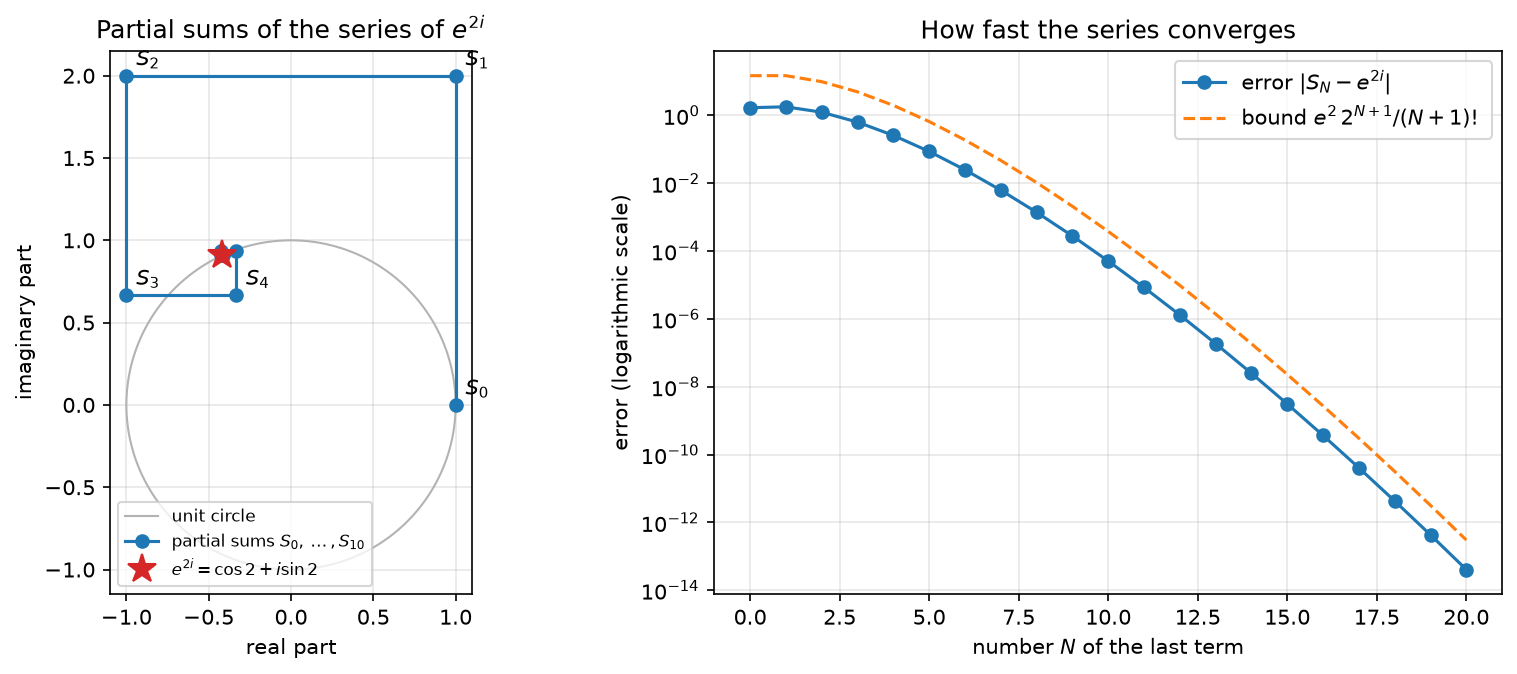

Figure 01b.2 saved as Revision/textbook/figures/01b_2_euler_series.png


In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.6))
circle = np.exp(1j * np.linspace(0.0, 2.0 * np.pi, 400))  # the unit circle
left.plot(circle.real, circle.imag, color="0.7", lw=1, label="unit circle")
first = np.array(partial_sums[:11])
left.plot(first.real, first.imag, "o-", color="tab:blue",
          label="partial sums $S_0, \\dots, S_{10}$")
for n in range(5):  # number the first five points
    left.text(first[n].real + 0.06, first[n].imag + 0.06, f"$S_{n}$")
left.plot([target.real], [target.imag], "*", color="tab:red", ms=14,
          label="$e^{2i} = \\cos 2 + i \\sin 2$")
left.set_aspect("equal")
left.set_xlabel("real part")
left.set_ylabel("imaginary part")
left.set_title("Partial sums of the series of $e^{2i}$")
left.legend(loc="lower left", fontsize=8)
right.semilogy(range(21), errors, "o-", label="error $|S_N - e^{2i}|$")
right.semilogy(range(21), bounds, "--", label="bound $e^2 \\, 2^{N+1}/(N+1)!$")
right.set_xlabel("number $N$ of the last term")
right.set_ylabel("error (logarithmic scale)")
right.set_title("How fast the series converges")
right.legend()
fig.tight_layout()
save_figure(fig, "euler_series",
            "Left: the partial sums $S_N = \\sum_{k=0}^{N} (2i)^k/k!$ for $N = 0$ to "
            "10 in the complex plane (blue points joined in order, the first five "
            "labelled), the unit circle (grey) and the point $e^{2i} = \\cos 2 + "
            "i \\sin 2$ (red star); axes real and imaginary part. The partial sums "
            "turn around the origin and close in on the star. Right: the error "
            "$|S_N - e^{2i}|$ against $N$ on a logarithmic scale (circles) and the "
            "bound $e^2 2^{N+1}/(N+1)!$ (dashed); the error falls faster than any "
            "power of 10 per step once $N$ exceeds about 4.")

The next cell repeats Euler's formula with mpmath at 50 significant digits, in
particular $e^{i\pi} = -1$ (mpmath stores $\pi$ itself with 50 digits, so a
leftover imaginary part of about $10^{-51}$ appears; it is the rounding of $\pi$,
not an error of the formula), and proves the law of exponents
$e^{i\alpha} e^{i\beta} = e^{i(\alpha + \beta)}$ exactly with sympy: multiplied
out, the left side is
$(\cos\alpha\cos\beta - \sin\alpha\sin\beta) + i(\sin\alpha\cos\beta +
\cos\alpha\sin\beta)$, which by the addition theorems is
$\cos(\alpha + \beta) + i \sin(\alpha + \beta)$. sympy's `expand_trig` writes out
the addition theorems.

In [7]:
mpmath.mp.dps = 50  # work with 50 significant digits
i_mp = mpmath.mpc(0, 1)  # the imaginary unit as an mpmath number
euler_gap = abs(mpmath.exp(i_mp * 2) - (mpmath.cos(2) + i_mp * mpmath.sin(2)))
pi_gap = abs(mpmath.exp(i_mp * mpmath.pi) + 1)
e_i_pi = mpmath.exp(i_mp * mpmath.pi)
# pi itself is stored with 50 digits, so a tiny imaginary part of about 1e-51 is
# left over: the rounding of pi, not a failure of the formula.
say(f"e^(i pi): real part {mpmath.nstr(e_i_pi.real, 30)}, imaginary part of size "
    f"{mpmath.nstr(abs(e_i_pi.imag), 2)}")
check(euler_gap < mpmath.mpf("1e-45") and pi_gap < mpmath.mpf("1e-45"),
      "mpmath, 50 digits: e^(2i) = cos 2 + i sin 2 and e^(i pi) = -1")
alpha, beta = sp.symbols("alpha beta", real=True)
left_side = sp.expand((sp.cos(alpha) + I * sp.sin(alpha))
                      * (sp.cos(beta) + I * sp.sin(beta)))
right_side = sp.expand(sp.expand_trig(sp.cos(alpha + beta) + I * sp.sin(alpha + beta)))
check(sp.expand(left_side - right_side) == 0,
      "sympy: e^(i alpha) e^(i beta) = e^(i (alpha + beta)) for all real angles")

e^(i pi): real part -1.0, imaginary part of size 1.0e-51
PASS mpmath, 50 digits: e^(2i) = cos 2 + i sin 2 and e^(i pi) = -1
PASS sympy: e^(i alpha) e^(i beta) = e^(i (alpha + beta)) for all real angles


## 8. Multiplying by a complex number rotates and stretches

Write $u = r e^{i\alpha}$ and a point of the plane as $p = \rho e^{i\varphi}$.
Then $up = r\rho \, e^{i(\alpha + \varphi)}$ by the law of exponents: the length
is multiplied by $r$ and the angle increased by $\alpha$. For $r = 1$ the
multiplication is a pure rotation.

The next cell draws the outline of the letter F (chosen because its mirror image
looks different, so a mirror would be noticed), and its images under
multiplication by $e^{i\pi/3}$ (60 degrees), $e^{5i\pi/6}$ (150 degrees) and
$0.6\,e^{-i\pi/2}$ (a quarter turn clockwise and a shrinking to 0.6). It checks
that the rotations keep the distance of every corner from the origin and turn
its angle by exactly $\alpha$.

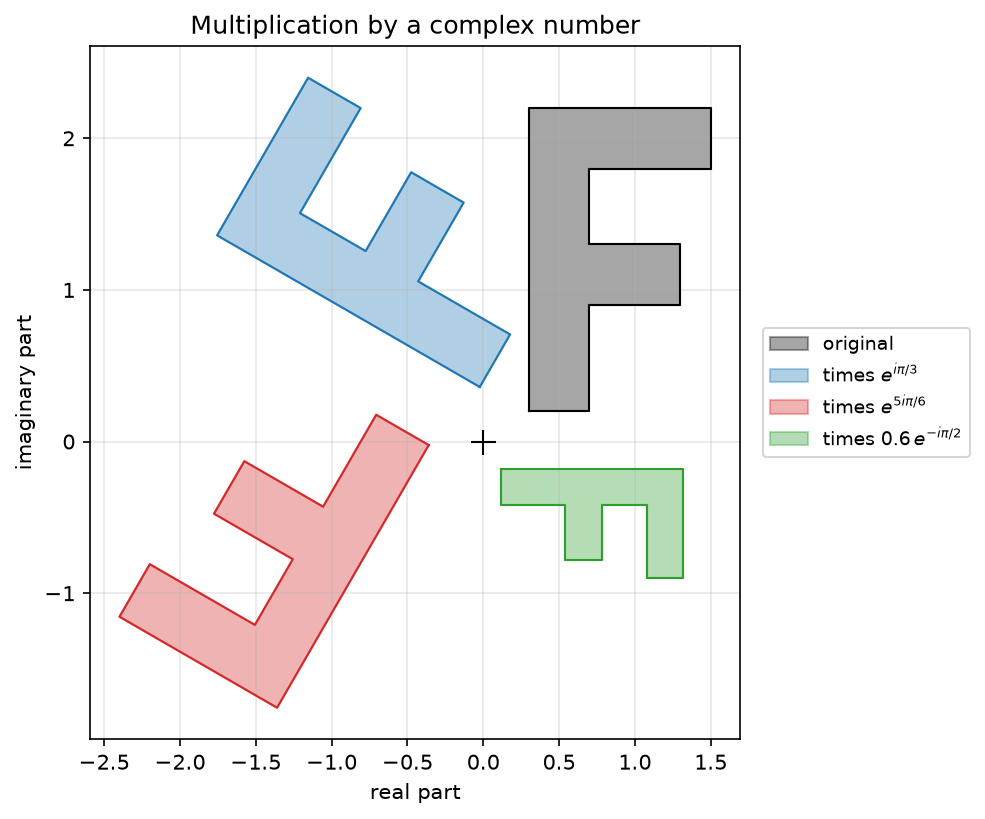

Figure 01b.3 saved as Revision/textbook/figures/01b_3_rotation_by_multiplication.png
PASS multiplying by e^(i alpha) keeps lengths and adds alpha to every angle


In [8]:
letter_f = np.array([0, 2j, 1.2 + 2j, 1.2 + 1.6j, 0.4 + 1.6j, 0.4 + 1.1j, 1.0 + 1.1j,
                     1.0 + 0.7j, 0.4 + 0.7j, 0.4, 0]) + (0.3 + 0.2j)  # corners
factors = [(1, "original", "black"),
           (np.exp(1j * np.pi / 3), "times $e^{i\\pi/3}$", "tab:blue"),
           (np.exp(5j * np.pi / 6), "times $e^{5i\\pi/6}$", "tab:red"),
           (0.6 * np.exp(-1j * np.pi / 2), "times $0.6\\,e^{-i\\pi/2}$", "tab:green")]
fig, ax = plt.subplots(figsize=(8.4, 6.0))
for factor, label, color in factors:
    image = factor * letter_f  # every corner multiplied by the factor
    ax.fill(image.real, image.imag, color=color, alpha=0.35, label=label)
    ax.plot(image.real, image.imag, color=color, lw=1)
ax.plot([0], [0], "k+", ms=12)  # the origin, the centre of the rotations
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Multiplication by a complex number")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
save_figure(fig, "rotation_by_multiplication",
            "The letter F (black) and its images after multiplying every corner by "
            "$e^{i\\pi/3}$ (blue, a turn by 60 degrees), by $e^{5i\\pi/6}$ (red, a "
            "turn by 150 degrees) and by $0.6\\,e^{-i\\pi/2}$ (green, a quarter turn "
            "clockwise and a shrinking to 0.6); horizontal axis the real part, "
            "vertical axis the imaginary part, the cross marks the origin. The "
            "letter is turned about the origin and never mirrored.")
rotations_ok = True
for alpha_value in (np.pi / 3, 5 * np.pi / 6):
    image = np.exp(1j * alpha_value) * letter_f
    rotations_ok &= bool(np.max(np.abs(np.abs(image) - np.abs(letter_f))) < 1e-14)
    turned = np.angle(image / letter_f)  # the change of every angle
    rotations_ok &= bool(np.max(np.abs(turned - alpha_value)) < 1e-12)
check(rotations_ok, "multiplying by e^(i alpha) keeps lengths and adds alpha to "
      "every angle")

## 9. The same rotation as a real 2 x 2 matrix

Multiplying $x + iy$ by $a + ib$ gives $(ax - by) + i(bx + ay)$. Written for the
pair $(x, y)$ this is the matrix product

$$\begin{pmatrix} a & -b \\ b & a \end{pmatrix}
\begin{pmatrix} x \\ y \end{pmatrix} =
\begin{pmatrix} ax - by \\ bx + ay \end{pmatrix}.$$

So every complex number $a + ib$ has a real matrix $M(a + ib)$ with the rows
$(a, -b)$ and $(b, a)$. The number 1 has the identity matrix and $i$ has the
matrix $J$ with rows $(0, -1)$ and $(1, 0)$. The next cell checks, exactly with
sympy, that

- $J^2 = -I$: a *real* matrix plays the role of $i$;
- $M(z) M(w) = M(zw)$ for all $z$ and $w$: multiplying matrices is the same as
  multiplying the numbers;
- $\det M(a + ib) = a^2 + b^2 = |z|^2$;
- the rotation matrix $R(\alpha) = M(e^{i\alpha})$ obeys
  $R(\alpha) R(\beta) = R(\alpha + \beta)$, $\det R(\alpha) = 1$ and
  $R(\alpha)^T R(\alpha) = I$ (so it keeps $x^2 + y^2$).

It also checks in numbers that rotating the corners of the letter F with
$R(\pi/3)$ gives the same points as multiplying them by $e^{i\pi/3}$.

In [9]:
def M(re_part, im_part):
    """The real 2 x 2 matrix of the complex number re_part + i im_part."""
    return sp.Matrix([[re_part, -im_part], [im_part, re_part]])


J = M(0, 1)  # the matrix of i
check(J * J == -sp.eye(2), "J J = -I: the real matrix J behaves like i")
zw_re, zw_im = a * c - b * d, a * d + b * c  # z w = (ac - bd) + i (ad + bc)
check((M(a, b) * M(c, d) - M(zw_re, zw_im)).expand() == sp.zeros(2, 2),
      "M(z) M(w) = M(z w) for all complex z and w")
check(sp.expand(M(a, b).det()) == a ** 2 + b ** 2, "det M(a + i b) = a^2 + b^2")


def R(angle):
    """The rotation matrix of the angle: the matrix of e^(i angle)."""
    return M(sp.cos(angle), sp.sin(angle))


product_rule = (R(alpha) * R(beta) - R(alpha + beta)).applyfunc(sp.expand_trig)
check(product_rule.expand() == sp.zeros(2, 2), "R(alpha) R(beta) = R(alpha + beta)")
check(sp.simplify(R(alpha).det()) == 1 and
      (R(alpha).T * R(alpha)).applyfunc(sp.simplify) == sp.eye(2),
      "det R(alpha) = 1 and R(alpha)^T R(alpha) = I")
rotation = np.array(R(sp.pi / 3).evalf(), dtype=float)  # R(pi/3) as numbers
corners = np.array([letter_f.real, letter_f.imag])  # 2 rows: x and y of each corner
by_matrix = rotation @ corners
by_number = np.exp(1j * np.pi / 3) * letter_f
check(np.max(np.abs(by_matrix[0] + 1j * by_matrix[1] - by_number)) < 1e-14,
      "the rotation matrix R(pi/3) moves the corners exactly like e^(i pi/3)")

PASS J J = -I: the real matrix J behaves like i
PASS M(z) M(w) = M(z w) for all complex z and w
PASS det M(a + i b) = a^2 + b^2
PASS R(alpha) R(beta) = R(alpha + beta)
PASS det R(alpha) = 1 and R(alpha)^T R(alpha) = I
PASS the rotation matrix R(pi/3) moves the corners exactly like e^(i pi/3)


## 10. The roots of unity

The numbers $z_k = e^{2\pi i k/n}$, $k = 0, 1, \dots, n-1$, satisfy
$z_k^n = e^{2\pi i k} = 1$: they are the $n$ roots of unity. They are the corners
of a regular polygon with $n$ sides on the unit circle, and their sum is 0 (the
sum is unchanged when every $z_k$ is multiplied by $z_1$, which only re-orders
them; a number that does not change when multiplied by $z_1 \neq 1$ must be 0).

The next cell checks this in numbers for $n = 3$ and $n = 8$, writes the eight
eighth roots exactly with sympy (`expand_complex` writes a number as real part
plus $i$ times imaginary part), checks their eighth powers and their sum exactly,
and draws both polygons.

PASS the 3 roots of unity of order 3: z^3 = 1 and their sum is 0
PASS the 8 roots of unity of order 8: z^8 = 1 and their sum is 0
the eighth roots of unity, exactly: 1, sqrt(2)/2 + sqrt(2)*I/2, I, -sqrt(2)/2 +
    sqrt(2)*I/2, -1, -sqrt(2)/2 - sqrt(2)*I/2, -I, sqrt(2)/2 - sqrt(2)*I/2
PASS sympy: each exact eighth root has eighth power 1, and they add up to 0


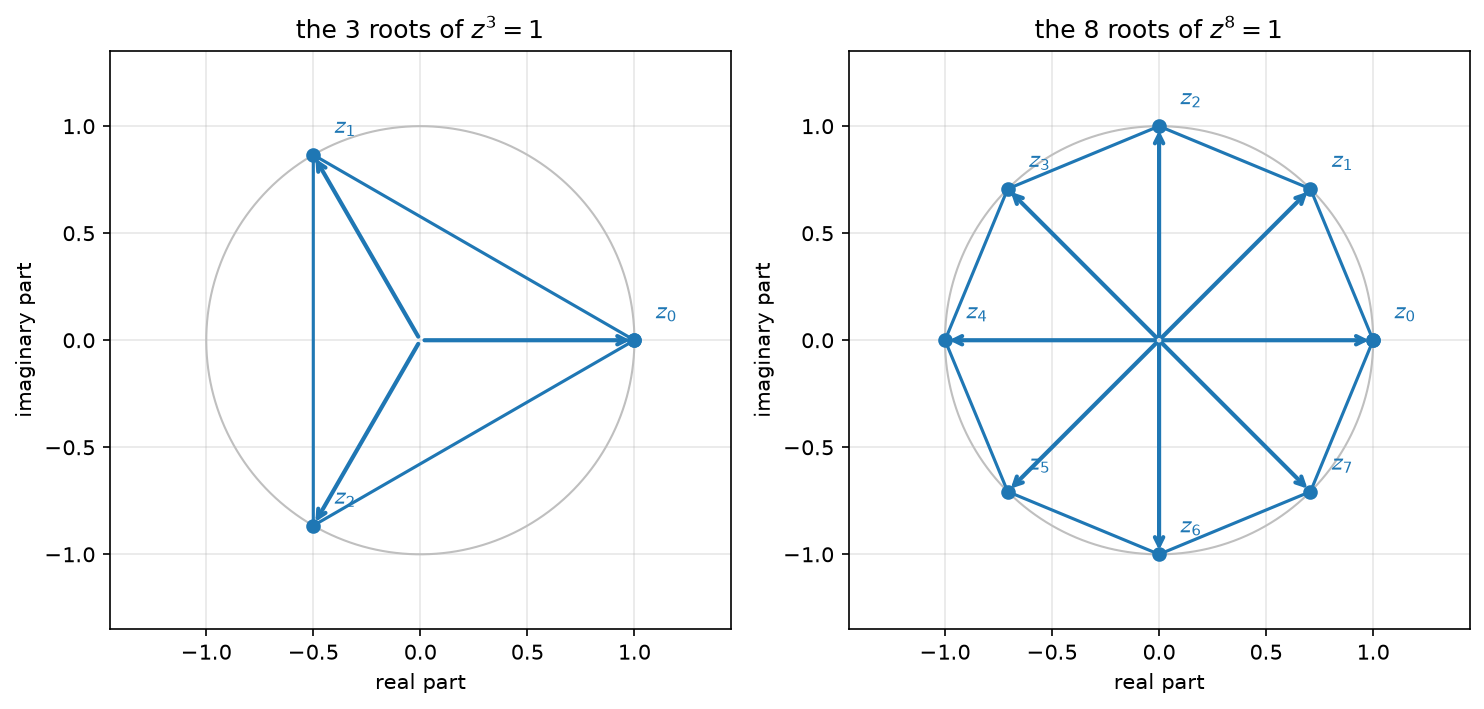

Figure 01b.4 saved as Revision/textbook/figures/01b_4_roots_of_unity.png


In [10]:
for n in (3, 8):
    roots = np.exp(2j * np.pi * np.arange(n) / n)  # e^(2 pi i k/n), k = 0 ... n-1
    check(np.max(np.abs(roots ** n - 1)) < 1e-12 and abs(roots.sum()) < 1e-12,
          f"the {n} roots of unity of order {n}: z^{n} = 1 and their sum is 0")
eighth = [sp.expand_complex(sp.exp(2 * sp.pi * I * k / 8)) for k in range(8)]
say("the eighth roots of unity, exactly: " + ", ".join(str(r) for r in eighth))
check(all(sp.simplify(r ** 8 - 1) == 0 for r in eighth) and
      sp.simplify(sum(eighth)) == 0,
      "sympy: each exact eighth root has eighth power 1, and they add up to 0")
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.8))
for ax, n in zip(axes, (3, 8)):
    roots = np.exp(2j * np.pi * np.arange(n + 1) / n)  # the first root again at the end
    ax.plot(circle.real, circle.imag, color="0.75", lw=1)
    ax.plot(roots.real, roots.imag, "o-", color="tab:blue")
    for k in range(n):
        arrow(ax, roots[k], "tab:blue", f"$z_{k}$")
    ax.set_aspect("equal")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xlabel("real part")
    ax.set_ylabel("imaginary part")
    ax.set_title(f"the {n} roots of $z^{n} = 1$")
fig.tight_layout()
save_figure(fig, "roots_of_unity",
            "The roots of unity $z_k = e^{2\\pi i k/n}$ for $n = 3$ (left) and "
            "$n = 8$ (right) as arrows from the origin to the unit circle (grey); "
            "axes real and imaginary part. They are the corners of a regular "
            "triangle and a regular octagon; the arrows of each picture add up to "
            "zero.")

## 11. Conjugation and real numbers

Conjugation changes the sign of the imaginary part and nothing else. So a real
number, which has imaginary part 0, is its own conjugate: $x^* = x$; and a list
of real numbers is not changed at all by conjugating every entry. Conjugating
twice gives back the original number, and the conjugate of $e^{i\alpha}$ is
$e^{-i\alpha}$: conjugation turns a rotation into the opposite rotation.

This simple fact matters later in the course: the author's gamma matrices are
real, and for real quantities conjugation does nothing at all. An operation that
is meant to change a real field must therefore be built from a *matrix*. The
next cell checks the four statements with numpy (`.conj()` conjugates every
entry of an array).

In [11]:
v_real = np.array([0.5, -2.0, 3.0])  # a list of real numbers
v_complex = np.array([1 + 2j, -1j, 4.0])  # a list with imaginary parts
check((v_real.conj() == v_real).all(),
      "conjugation leaves a list of real numbers unchanged")
check(not (v_complex.conj() == v_complex).all(),
      "conjugation changes a list whose imaginary parts are not all 0")
check((v_complex.conj().conj() == v_complex).all(),
      "conjugating twice gives back the original list")
check(abs(np.exp(0.7j).conjugate() - np.exp(-0.7j)) < 1e-15,
      "the conjugate of e^(i alpha) is e^(-i alpha)")

PASS conjugation leaves a list of real numbers unchanged
PASS conjugation changes a list whose imaginary parts are not all 0
PASS conjugating twice gives back the original list
PASS the conjugate of e^(i alpha) is e^(-i alpha)


## 12. Rotations and boosts

A rotation mixes two directions of the same kind and keeps $x^2 + y^2$. A boost
mixes a time-like coordinate $t$ with a space-like coordinate $x$:

$$\begin{pmatrix} t' \\ x' \end{pmatrix} =
\begin{pmatrix} \cosh\varphi & \sinh\varphi \\ \sinh\varphi & \cosh\varphi
\end{pmatrix} \begin{pmatrix} t \\ x \end{pmatrix}.$$

With the frame metric of this pair, $\eta = \mathrm{diag}(-1, +1)$ ($t$ is
time-like, $x$ space-like, as $x_4$ and $x_8$ in the author's coordinates), the
boost $\Lambda$ satisfies $\Lambda^T \eta \Lambda = \eta$, which says that
$-t'^2 + x'^2 = -t^2 + x^2$; it follows from $\cosh^2 - \sinh^2 = 1$. The next
cell checks exactly with sympy:

- $\Lambda^T \eta \Lambda = \eta$ and $\det \Lambda = 1$;
- rapidities add: $\Lambda(\varphi_1) \Lambda(\varphi_2) = \Lambda(\varphi_1 +
  \varphi_2)$ (the addition theorems of $\cosh$ and $\sinh$);
- the two light-like directions $(t, x) = (1, 1)$ and $(1, -1)$ are only
  stretched: $\Lambda (1, 1) = e^{\varphi} (1, 1)$ and
  $\Lambda (1, -1) = e^{-\varphi} (1, -1)$, because
  $\cosh\varphi \pm \sinh\varphi = e^{\pm\varphi}$.

In [12]:
phi, phi1, phi2 = sp.symbols("phi phi1 phi2", real=True)


def boost(rapidity):
    """The boost matrix acting on the pair (t, x)."""
    return sp.Matrix([[sp.cosh(rapidity), sp.sinh(rapidity)],
                      [sp.sinh(rapidity), sp.cosh(rapidity)]])


eta_tx = sp.diag(-1, 1)  # t time-like (-1), x space-like (+1)
L = boost(phi)
check((L.T * eta_tx * L - eta_tx).applyfunc(sp.simplify) == sp.zeros(2, 2) and
      sp.simplify(L.det()) == 1,
      "a boost keeps -t^2 + x^2 (Lambda^T eta Lambda = eta) and has det 1")
added = (boost(phi1) * boost(phi2) - boost(phi1 + phi2)).applyfunc(sp.expand_trig)
check(added.expand() == sp.zeros(2, 2), "rapidities add: boost(phi1) boost(phi2) = "
      "boost(phi1 + phi2)")
light_plus = (L * sp.Matrix([1, 1]) - sp.exp(phi) * sp.Matrix([1, 1]))
light_minus = (L * sp.Matrix([1, -1]) - sp.exp(-phi) * sp.Matrix([1, -1]))
# rewrite(sp.exp) writes cosh and sinh with exponentials, then simplify:
check(light_plus.applyfunc(lambda e: sp.simplify(e.rewrite(sp.exp)))
      == sp.zeros(2, 1) and
      light_minus.applyfunc(lambda e: sp.simplify(e.rewrite(sp.exp)))
      == sp.zeros(2, 1),
      "the light-like directions are stretched by e^phi and by e^(-phi)")

PASS a boost keeps -t^2 + x^2 (Lambda^T eta Lambda = eta) and has det 1
PASS rapidities add: boost(phi1) boost(phi2) = boost(phi1 + phi2)
PASS the light-like directions are stretched by e^phi and by e^(-phi)


The next cell draws what the two kinds of transformation do to one point. Left:
the point $(1, 0)$ rotated by angles from 0 to $2\pi$ runs around the circle
$x^2 + y^2 = 1$. Right: the event $(t, x) = (1, 0)$ boosted with rapidities from
$-2$ to $2$ runs along the hyperbola $t^2 - x^2 = 1$ and never crosses the two
light-like lines $t = \pm x$. The points for the angles and rapidities
$-1, -0.5, 0, 0.5, 1$ are marked.

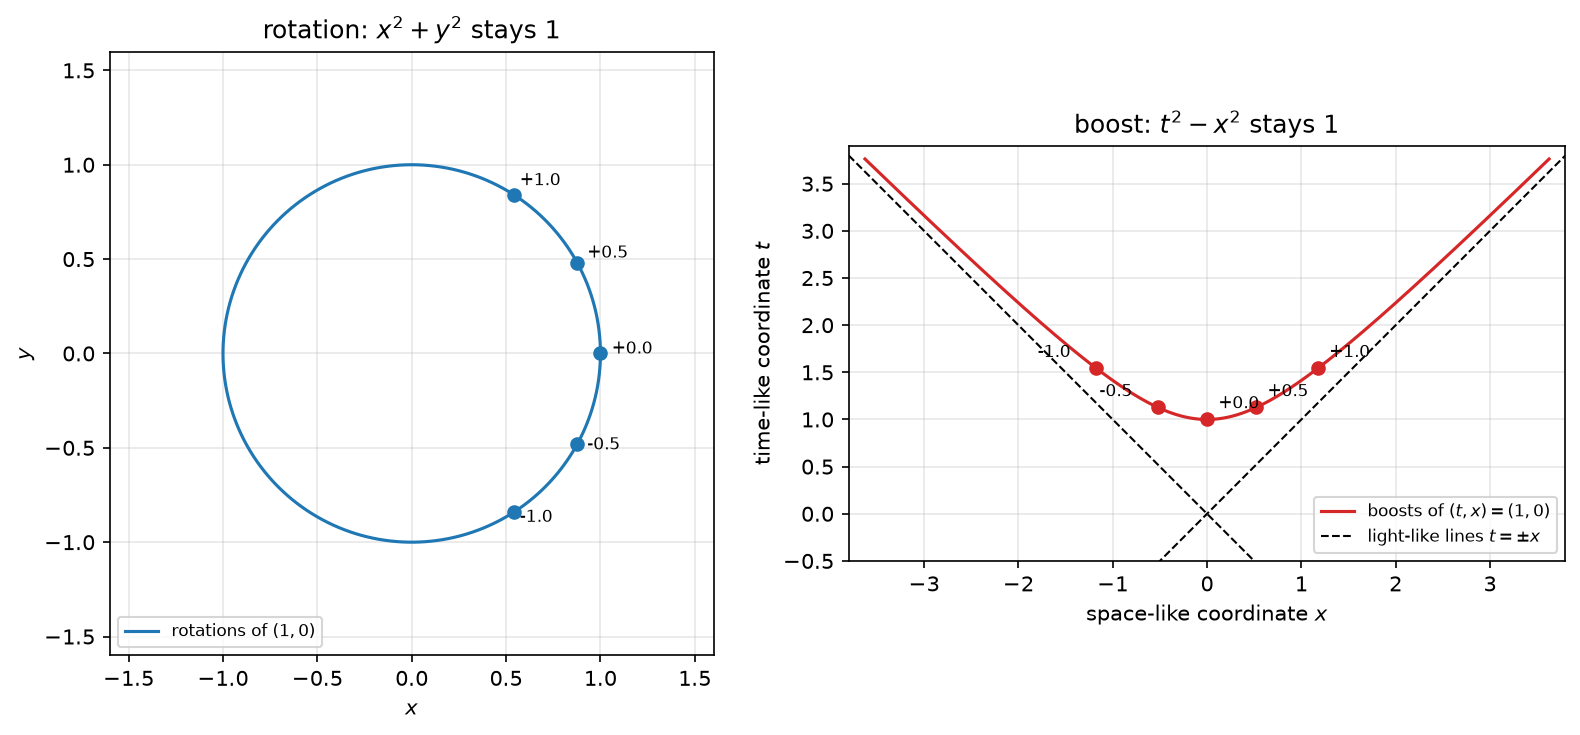

Figure 01b.5 saved as Revision/textbook/figures/01b_5_rotations_and_boosts.png
PASS numbers: cosh^2 - sinh^2 = 1 at 400 rapidities from -2 to 2


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 5.0))
angles = np.linspace(0.0, 2.0 * np.pi, 400)
left.plot(np.cos(angles), np.sin(angles), color="tab:blue",
          label="rotations of $(1, 0)$")
marks = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
left.plot(np.cos(marks), np.sin(marks), "o", color="tab:blue")
for value in marks:
    left.text(1.06 * np.cos(value), 1.06 * np.sin(value), f"{value:+.1f}", fontsize=8)
left.set_aspect("equal")
left.set_xlim(-1.6, 1.6)
left.set_ylim(-1.6, 1.6)
left.set_xlabel("$x$")
left.set_ylabel("$y$")
left.set_title("rotation: $x^2 + y^2$ stays 1")
left.legend(loc="lower left", fontsize=8)
rapidities = np.linspace(-2.0, 2.0, 400)
right.plot(np.sinh(rapidities), np.cosh(rapidities), color="tab:red",
           label="boosts of $(t, x) = (1, 0)$")
right.plot(np.sinh(marks), np.cosh(marks), "o", color="tab:red")
for value in marks:  # labels left of the points on the left half, right otherwise
    shift = 0.12 if value >= 0 else -0.62
    right.text(np.sinh(value) + shift, np.cosh(value) + 0.12, f"{value:+.1f}",
               fontsize=8)
edge = np.linspace(-3.8, 3.8, 2)
right.plot(edge, edge, "k--", lw=1, label="light-like lines $t = \\pm x$")
right.plot(edge, -edge, "k--", lw=1)
right.set_aspect("equal")
right.set_xlim(-3.8, 3.8)
right.set_ylim(-0.5, 3.9)
right.set_xlabel("space-like coordinate $x$")
right.set_ylabel("time-like coordinate $t$")
right.set_title("boost: $t^2 - x^2$ stays 1")
right.legend(loc="lower right", fontsize=8)
fig.tight_layout()
save_figure(fig, "rotations_and_boosts",
            "Left: the point $(1, 0)$ rotated by all angles from 0 to $2\\pi$ "
            "(blue circle $x^2 + y^2 = 1$; the dots are the angles $-1$ to $1$ in "
            "steps of 0.5); axes $x$ and $y$. Right: the event $(t, x) = (1, 0)$ "
            "boosted with rapidities from $-2$ to $2$ (red hyperbola "
            "$t^2 - x^2 = 1$; the dots are the rapidities $-1$ to $1$ in steps of "
            "0.5) and the light-like lines $t = \\pm x$ (dashed); horizontal axis "
            "the space-like $x$, vertical axis the time-like $t$ (pure numbers). "
            "A rotation keeps a circle, a boost keeps a hyperbola.")
on_hyperbola = np.cosh(rapidities) ** 2 - np.sinh(rapidities) ** 2
check(np.max(np.abs(on_hyperbola - 1)) < 1e-12,
      "numbers: cosh^2 - sinh^2 = 1 at 400 rapidities from -2 to 2")

## 13. Oscillation and growth

For a real frequency $\varepsilon$ the wave $e^{-i\varepsilon t} =
\cos(\varepsilon t) - i \sin(\varepsilon t)$ has modulus 1 at all times: its real
and imaginary parts oscillate. For an imaginary frequency $\varepsilon = i\gamma$
($\gamma$ real) the same formula gives $e^{-i(i\gamma)t} = e^{\gamma t}$: no
oscillation, but exponential growth for $\gamma > 0$ (and decay for
$\gamma < 0$). A complex frequency $\varepsilon = 2 + 0.3i$ gives
$e^{-i\varepsilon t} = e^{0.3t} e^{-2it}$: an oscillation whose size grows like
$e^{0.3t}$.

The next cell checks these three statements at 501 times from 0 to 10 and draws
them.

PASS real frequency: |e^(-i eps t)| = 1 at every time
PASS imaginary frequency 0.3 i: e^(-i eps t) = e^(0.3 t), real and growing
PASS complex frequency 2 + 0.3 i: the size of the wave is e^(0.3 t)


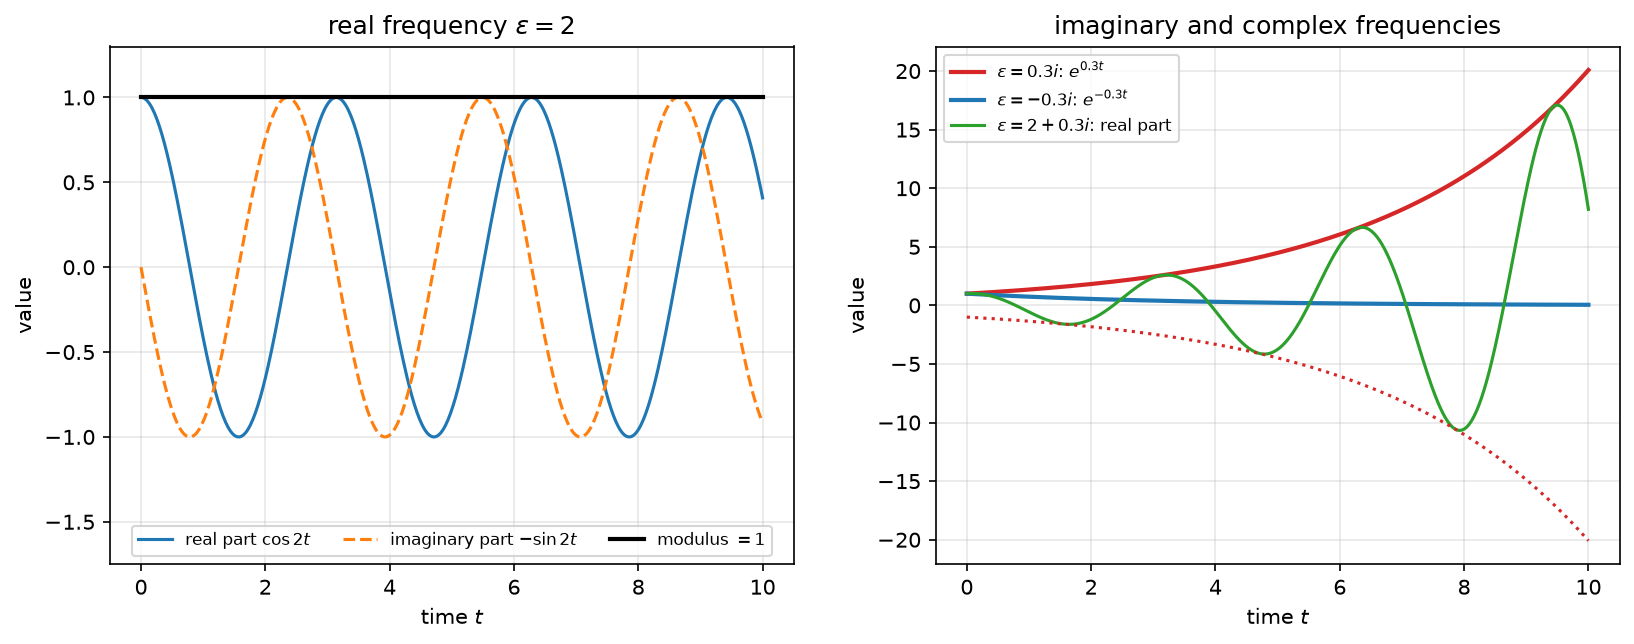

Figure 01b.6 saved as Revision/textbook/figures/01b_6_oscillation_and_growth.png


In [14]:
t = np.linspace(0.0, 10.0, 501)
wave = np.exp(-1j * 2.0 * t)  # real frequency 2
growing = np.exp(-1j * (0.3j) * t)  # imaginary frequency 0.3 i
decaying = np.exp(-1j * (-0.3j) * t)  # imaginary frequency -0.3 i
mixed = np.exp(-1j * (2.0 + 0.3j) * t)  # complex frequency 2 + 0.3 i
check(np.max(np.abs(np.abs(wave) - 1.0)) < 1e-14,
      "real frequency: |e^(-i eps t)| = 1 at every time")
check(np.max(np.abs(growing - np.exp(0.3 * t))) < 1e-12 * np.exp(3.0),
      "imaginary frequency 0.3 i: e^(-i eps t) = e^(0.3 t), real and growing")
check(np.max(np.abs(np.abs(mixed) - np.exp(0.3 * t))) < 1e-12 * np.exp(3.0),
      "complex frequency 2 + 0.3 i: the size of the wave is e^(0.3 t)")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.4))
left.plot(t, wave.real, label="real part $\\cos 2t$")
left.plot(t, wave.imag, "--", label="imaginary part $-\\sin 2t$")
left.plot(t, np.abs(wave), color="black", lw=2, label="modulus $= 1$")
left.set_xlabel("time $t$")
left.set_ylabel("value")
left.set_title("real frequency $\\varepsilon = 2$")
left.set_ylim(-1.75, 1.3)  # room below the curves for the legend
left.legend(loc="lower center", ncol=3, fontsize=8)
right.plot(t, growing.real, color="tab:red", lw=2,
           label="$\\varepsilon = 0.3i$: $e^{0.3t}$")
right.plot(t, decaying.real, color="tab:blue", lw=2,
           label="$\\varepsilon = -0.3i$: $e^{-0.3t}$")
right.plot(t, mixed.real, color="tab:green",
           label="$\\varepsilon = 2 + 0.3i$: real part")
right.plot(t, -np.exp(0.3 * t), ":", color="tab:red")  # the lower envelope
right.set_xlabel("time $t$")
right.set_ylabel("value")
right.set_title("imaginary and complex frequencies")
right.legend(loc="upper left", fontsize=8)
fig.tight_layout()
save_figure(fig, "oscillation_and_growth",
            "Left: the wave $e^{-i\\varepsilon t}$ with the real frequency "
            "$\\varepsilon = 2$; its real part (solid) and imaginary part (dashed) "
            "oscillate and its modulus (thick black) stays 1. Right: imaginary "
            "frequencies $\\varepsilon = 0.3i$ (red, growth $e^{0.3t}$) and "
            "$\\varepsilon = -0.3i$ (blue, decay $e^{-0.3t}$), and the real part of "
            "the wave with the complex frequency $2 + 0.3i$ (green), which "
            "oscillates between the curves $\\pm e^{0.3t}$ (red solid and dotted); "
            "horizontal axis the time $t$, vertical axis the value (pure numbers).")

## 14. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [15]:
figure_names = ["01b_1_complex_plane.png", "01b_2_euler_series.png",
                "01b_3_rotation_by_multiplication.png", "01b_4_roots_of_unity.png",
                "01b_5_rotations_and_boosts.png", "01b_6_oscillation_and_growth.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 33 CHECKS PASSED (notebook 01b)


## 15. What this notebook showed

- Complex numbers $a + ib$ obey the ordinary rules of algebra with $i^2 = -1$;
  $(zw)^* = z^* w^*$, $zz^* = |z|^2$ and $|zw| = |z|\,|w|$ hold for all of them
  (proved with sympy symbols).
- The exponential series at $i\theta$ converges to $\cos\theta + i\sin\theta$
  (Euler's formula); after 21 terms the error at $\theta = 2$ is below
  $10^{-12}$, and every error lies below the bound
  $e^\theta \theta^{N+1}/(N+1)!$; mpmath confirms $e^{i\pi} = -1$ to 50 digits.
- Multiplying by $e^{i\alpha}$ rotates the plane by $\alpha$; the same rotation
  is the real matrix $R(\alpha)$, and the real matrix $J$ of $i$ has $J^2 = -I$.
- The $n$ roots of unity are the corners of a regular polygon and add up to 0.
- Conjugation leaves real numbers, and lists of real numbers, unchanged.
- Rotations keep $x^2 + y^2$; boosts, which mix a time-like and a space-like
  direction, keep $x^2 - t^2$, add their rapidities, and stretch the two
  light-like directions by $e^{\varphi}$ and $e^{-\varphi}$.
- A real frequency gives an oscillation of constant size; an imaginary frequency
  gives exponential growth or decay.